# Example: GBM Net Present Value Trade Rule

What is the probability that buying a stock today and selling it after a fixed holding period exceeds a target discounted return?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Calculate NPV target probabilities using GBM:** Use a GBM model with estimated mean growth and volatility to describe the distribution of the future sale price. Use that distribution to calculate the probability of exceeding a target scaled NPV.
> * **Explain and apply the median check:** Calculate the median scaled NPV and explain why using it as the target gives an exceedance probability of one half.
> * **Interpret the effect of the target:** Explain why raising the target lowers the probability of exceeding it, and why exceeding a negative target can still mean a discounted loss.

In this example, we use a geometric Brownian motion (GBM) model with parameters estimated in the previous example to describe the distribution of the future sale price. We then apply the lecture’s net present value (NPV) trade rule to calculate the probability of exceeding a chosen discounted return.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

__Data.__ We use the GBM parameter estimates saved in the [previous example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). Each row contains a firm's ticker, estimated mean growth rate, and volatility.

Let's load [`SAGBM-Parameters-Fall-2025.csv`](data/npv/SAGBM-Parameters-Fall-2025.csv) into `parameters_df::DataFrame`. The `drift` column stores the mean-growth estimate $\hat{\mu}_g$, and the `volatility` column stores $\hat{\sigma}$:


In [2]:
parameters_df = let

    # Load the saved mean-growth and volatility estimates -
    df = CSV.read(joinpath(_PATH_TO_DATA,"npv","SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df;
end;

__Constants.__ Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units:


In [3]:
TSIM = 63;    # holding period (trading days)
Δt = 1/252;   # duration of one trading day (years)
g_y = 0.05;   # continuously compounded annual benchmark growth rate (1/year)

target_min = -0.20;      # smallest target scaled NPV (must exceed -1)
target_max = 0.40;       # largest target scaled NPV
number_of_targets = 201; # number of evenly spaced targets


___

## Task 1: Calculate the Target Probability
In this task, we select a firm and a target discounted return, then use the lecture’s formula to calculate the probability of exceeding that target under GBM. 

Let $g_y$ be the constant, continuously compounded annual growth rate associated with the selected benchmark yield $y$, and let $T$ be the holding period in years. Recall from the lecture that, for a purchase price $S_0>0$ and a sale price $S_T$, both in USD/share, the scaled NPV is given by:

$$
\rho_T=\left(\frac{S_T}{S_0}\right)e^{-g_yT}-1.
$$

This dimensionless quantity is the net present value divided by the initial investment. It measures the discounted fractional return: a positive value means that the present value of the sale proceeds exceeds the purchase cost.

We choose a target scaled NPV $\rho_{\star}>-1$ and ask for the probability that $\rho_T$ exceeds it at the scheduled sale time $T$. Under GBM with $\sigma>0$ and a holding period $T>0$, this probability is given by:

$$
\mathbb{P}\left(\rho_{T}>\rho_{\star}\right) = 1-\Phi\left(\frac{\ln(1+\rho_{\star}) + g_yT - \mu_g\,T}{\sigma\sqrt{T}}\right).
$$

Here, $\mu_g=\mu-\sigma^{2}/2$ is the mean growth rate, and $\Phi(\cdot)$ is the standard normal cumulative distribution function. We evaluate this probability using the estimates $\hat{\mu}_g$ and $\hat{\sigma}$ from the parameter table. Let's start by selecting a firm from our parameter table. 

You can change the value of the `selected_firm_ticker::String` variable to analyze a different firm:

In [4]:
selected_firm_ticker = "AAPL"; # firm whose saved parameters define the price model

Next, let's specify the target scaled NPV, `ρ_star`. A negative target allows a discounted loss; zero requires a positive NPV; and a positive target requires a discounted gain:


In [5]:
ρ_star = -0.15; # target scaled NPV (dimensionless; must exceed -1)


Under GBM, the log-price change is normally distributed. The quantity `z` measures how many standard deviations the required log-price change lies above or below its model mean. The standard normal probability above `z` gives the probability of exceeding our target.

In [6]:
let

    # Read the selected firm's parameters -
    i = findfirst(==(selected_firm_ticker), parameters_df.ticker); # row of the selected firm in the parameter table
    μ̂_g = parameters_df[i,:drift]; # mean growth estimate (1/year); legacy drift column
    σ̂ = parameters_df[i,:volatility]; # volatility estimate (1/sqrt(year))
    T = TSIM * Δt; # holding period (in years)
    d = Normal(); # standard normal distribution
    m = μ̂_g*T; # estimated mean of ln(S_T/S_0) under GBM: μ̂_g*T
    
    # Compute the probability of exceeding the target -
    z = (log1p(ρ_star) + g_y*T - m)/(σ̂*sqrt(T)); # target log-price change, measured in standard deviations
    p = ccdf(d, z); # probability that ρ_T > ρ⋆
    println("For $(selected_firm_ticker) with ρ_star=$(ρ_star), the P(ρ_T > ρ_star) in T = $(TSIM) days is p=$(round(p,digits=4)).");
end

For AAPL with ρ_star=-0.15, the P(ρ_T > ρ_star) in T = 63 days is p=0.9638.


__What does this probability mean?__ The printed value of `p` is the probability that the selected firm's discounted return exceeds `ρ_star` at the scheduled sale time. The complementary probability, `1-p`, is the probability of a discounted return at or below the target. When the target is negative, exceeding it can still include a discounted loss.


___

## Task 2: Verify the Calculation at the Median

In this task, we check our calculation of the probability that a trade exceeds a target discounted return. We choose the median scaled NPV as the target. The median divides this continuous distribution into two equally likely halves, so the probability of exceeding it is $1/2$.

Under GBM, the median log-price change is $\mu_gT$. Substituting this value into the scaled-NPV formula gives:

$$
\rho_{\mathrm{median}}=\exp\!\left[(\mu_g-g_y)T\right]-1.
$$

Let's use this target and confirm that our code returns a probability of $0.5$.


In [7]:
let
    # Set the target to the model median and verify its normal-tail probability -
    i = findfirst(==(selected_firm_ticker), parameters_df.ticker);
    μ̂_g = parameters_df[i,:drift]; # mean growth estimate (1/year); legacy drift column
    σ̂ = parameters_df[i,:volatility]; # volatility estimate (1/sqrt(year))
    T = TSIM*Δt; # holding period (years)
    ρ_median = exp(μ̂_g*T - g_y*T) - 1.0; # target equal to the median scaled NPV
    z = (log1p(ρ_median) + g_y*T - μ̂_g*T)/(σ̂*sqrt(T));
    p = ccdf(Normal(), z); # the median target gives z=0 and an upper tail of 0.5
    println("Median target ρ⋆ = $(round(ρ_median, digits=4)) gives P(ρ_T > ρ⋆) = $(p) (should be 0.5)");
    @assert isapprox(p, 0.5; atol=1e-12) "median check failed"
end

Median target ρ⋆ = 0.0494 gives P(ρ_T > ρ⋆) = 0.49999999999999983 (should be 0.5)


___

## Task 3: Explore the Probability Across Targets

In this task, we vary the target discounted return while keeping the firm, holding period, and benchmark rate fixed. We calculate the probability of exceeding each target and plot the resulting curve.

The constants `target_min`, `target_max`, and `number_of_targets` define the target range. We store the results in `P::Matrix{Float64}`, with one row per target: column 1 contains the target, and column 2 contains the probability of exceeding it.


In [8]:
P = let

    # Read the selected firm's parameters -
    i = findfirst(==(selected_firm_ticker), parameters_df.ticker); # row of the selected firm in the parameter table
    μ̂_g = parameters_df[i,:drift]; # mean growth estimate (1/year); legacy drift column
    σ̂ = parameters_df[i,:volatility]; # volatility estimate (1/sqrt(year))
    T = TSIM * Δt; # holding period (in years)
    d = Normal(); # standard normal distribution
    m = μ̂_g*T; # estimated mean of ln(S_T/S_0) under GBM

    f = range(target_min, stop=target_max, length=number_of_targets) |> collect; # range of targets ρ⋆
    P = Matrix{Float64}(undef, number_of_targets, 2); # columns: target scaled NPV, probability

    for i ∈ eachindex(f)
        # Compute the probability of exceeding f[i] -
        z = (log1p(f[i]) + g_y*T - m)/(σ̂*sqrt(T)); # target log-price change, measured in standard deviations
        p = ccdf(d, z); # probability that ρ_T > f[i]
        P[i,1] = f[i]; # target
        P[i,2] = p; # probability
    end

    P;
end;

Let's plot the probability of exceeding each target discounted return.


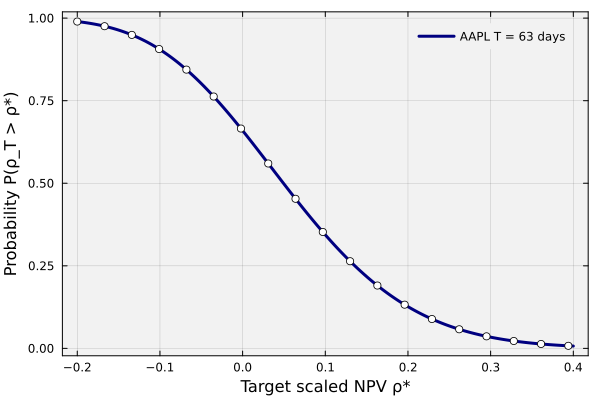

In [9]:
let

    # Plot all target probabilities and mark selected points -
    skip = 11; # place a marker on every eleventh target
    n = size(P,1);

    plot(P[:,1], P[:,2], c=:navy, lw=3, label="$(selected_firm_ticker) T = $(TSIM) days", legend=:topright);
    scatter!(P[1:skip:n,1], P[1:skip:n,2], c=:white, mec=:navy, ms=4, label="");
    xlabel!("Target scaled NPV ρ*");
    ylabel!("Probability P(ρ_T > ρ*)");

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

__What do we see?__ A higher target discounted return is harder to achieve, so its probability is lower. A negative target allows a limited discounted loss, while a positive target requires a discounted gain greater than the chosen target.


___

## Summary
In this example, we calculated the probability that a long position exceeds a target discounted return under GBM, verified the calculation at the median, and explored how the probability changes with the target.

> __Key Takeaways:__
>
> * **Target probability:** We used estimated GBM parameters and the normal distribution of log-price changes to calculate the probability that a trade exceeds a target discounted return.
> * **Median check:** We verified the probability calculation using the median scaled NPV as the target. Half the outcomes lie above this value, giving us a known result against which to check our code.
> * **Probability curve:** We varied the target discounted return while holding the firm, holding period, and benchmark rate fixed. The resulting curve showed how requiring a higher return lowers the probability of exceeding the target.

We can now repeat this analysis for a different firm, holding period, or benchmark rate to see how the target probabilities change.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
